# Scikit-Learn — Class Notes

**Topic:** Machine Learning with Scikit-Learn

**Key Concept:** Machine Learning (ML) is a branch of Artificial Intelligence that enables systems to learn patterns from data and make predictions or decisions without explicit programming. It is widely applied in domains like recommendation systems, fraud detection, natural language processing, and computer vision.

**Source:** [scikit-learn: machine learning in Python](https://scikit-learn.org/stable/index.html)

## What is Scikit-Learn?

Scikit-learn is a Python library that gives you ready-made machine learning tools. Instead of building algorithms from scratch, you import them and apply them to your data in just a few lines of code.

It offers a **consistent interface** for various machine learning algorithms, making it accessible to both beginners and experienced data scientists.

### Key Features
| Feature | What it does | Real-world examples |
|---------|-------------|-------------------|
| **Classification** | Identifies which category an object belongs to | Spam detection, image recognition |
| **Regression** | Predicts a continuous numeric value | Drug response, stock prices |
| **Clustering** | Automatically groups similar objects | Customer segmentation, grouping experiment outcomes |
| **Dimensionality Reduction** | Reduces the number of variables to consider | Visualization, increased efficiency |
| **Model Selection** | Compares, validates, and chooses parameters and models | Grid search, cross-validation |
| **Preprocessing** | Prepares raw data for use in ML algorithms | Feature extraction, normalization |

## The Scikit-Learn Estimator API

A **standardized programming interface** used in Scikit-learn for building and using machine learning models. It provides a consistent structure for:
- Creating models
- Training models
- Making predictions
- Evaluating results

>  **Think of it like a recipe:** every model in Scikit-learn follows the same steps, so once you learn the pattern, you can apply it to ANY model!

### The Estimator Sequence
Every model in Scikit-learn follows this exact 5-step pattern:

1. **Import the estimator** — bring in the algorithm you want to use
2. **Create the model object** — set up the model (like creating a blank form)
3. **Fit (train) the model** — feed it data so it can learn the pattern
4. **Predict results** — use the trained model on new data
5. **Evaluate performance** — check how accurate the model is

### Main Methods of the Estimator API
| Method | Purpose | When you use it |
|--------|---------|----------------|
| `.fit()` | Trains the model using data | Step 3 — always first |
| `.predict()` | Predicts outputs for new data | Step 4 — after fitting |
| `.score()` | Evaluates model accuracy/performance | Step 5 — to check results |
| `.transform()` | Modifies or scales data | Preprocessing step |
| `.fit_transform()` | Fits and transforms data together | Shortcut for preprocessing |

>  **Note:** `.fit()`, `.predict()`, and `.score()` are the 3 most important — highlighted in class as the core workflow!

### How the Estimator API Works (Visual)
```
.fit(X, y)          →     .predict(X_new)      →     .score(X_test, y_test)
Trains the model          Uses trained model          Evaluates how well
on training data          to make predictions         model performs
                                                      (R² Score = 0.98 = 98% accurate)
```

## Algorithm: Linear Regression

**Linear Regression** is a supervised machine learning algorithm that finds the best straight line through your data points to predict a numeric output.

- **X axis** = Independent Variable (the input, what you control or measure)
- **Y axis** = Dependent Variable (the output, what you're trying to predict)
- **Best Fit Line** = the line that comes closest to all the data points (also called the Regression Line)

### The Formula
y = mx + b
- **y** = the predicted value (what we want to find)
- **x** = the input value (what we know)
- **m** = slope (how steep the line is — how much y changes per unit of x)
- **b** = y-intercept (where the line crosses the y-axis when x = 0)

### Linear Regression answers questions like:
- What test score might a student get based on study hours?
- How much does a house cost based on its size?

### Steps for this Algorithm
1. Create a dataset of study hours vs exam scores
2. Split data into training and testing sets
3. Train a linear regression model
4. Predict exam scores
5. Evaluate the model
6. Visualize the regression line

## Linear Regression in Excel

Before doing it in Python, your instructor showed how to do linear regression in Excel using the **Analysis ToolPak** add-in. This is useful to understand the concepts visually before coding them.

### Step 1 — Enable the Analysis ToolPak
The Analysis ToolPak doesn't come turned on by default. To enable it:

**File > Options > Add-Ins > Analysis ToolPak > Go > Check the box > OK**

### Step 2 — Run the Regression
Once enabled, go to:

**Data > Data Analysis > Regression > OK**

### Step 3 — Create a Trendline
Using the Hours Studied vs Exam Score dataset, you can create a scatter plot and add a trendline to see the regression line visually. Excel will show you the equation:

y = 4.1576x + 47.333
R² = 0.9961

This matches what our Python model found! (slope ≈ 4.10, intercept ≈ 47.68)

### Step 4 — Read the Summary Output
Excel's regression output gives you a full statistics table:

| Statistic | Value | What it means |
|-----------|-------|---------------|
| **Multiple R** | 0.998 | Strength of the relationship (closer to 1 = stronger) |
| **R Square** | 0.996 | Model explains 99.6% of score variation |
| **Adjusted R Square** | 0.996 | R² adjusted for number of variables |
| **Standard Error** | 0.833 | Average amount predictions are off by |
| **Observations** | 10 | Number of data rows used |

| Coefficient | Value | What it means |
|-------------|-------|---------------|
| **Intercept** | 47.33 | Predicted score with 0 hours studied |
| **Hours Studied** | 4.16 | Each extra hour = ~4 more points on exam |

>  **Key takeaway:** Excel and Python give you the same answer! Excel is great for quick visual analysis, Python is better for larger datasets and automation.


Dataset:
   hours_studied  exam_score
0              1          52
1              2          55
2              3          60
3              4          65
4              5          68
5              6          72
6              7          75
7              8          80
8              9          85
9             10          90

Training set size: 8 rows
Testing set size:  2 rows

Model trained successfully.

Actual scores (real exam scores from test set):
[85, 55]

Predicted scores (what the model guessed):
[np.float64(84.6), np.float64(55.9)]

Slope (coefficient): 4.10
Intercept: 47.68

R² score: 0.998


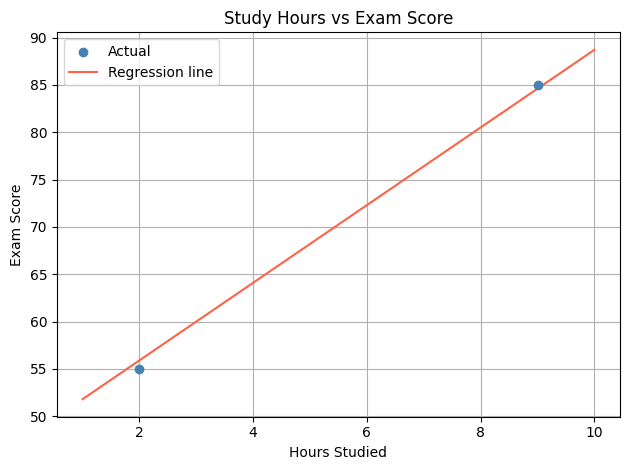

In [4]:
# ============================================================
# Regression Analysis with Scikit-Learn
# ============================================================
# WHAT THIS CODE DOES IN PLAIN ENGLISH:
# We have data showing how many hours students studied and what
# score they got on an exam. We want to teach a computer to
# PREDICT what score a NEW student will get based on their hours.
#
# We follow the 5-step Estimator API pattern:
# 1. Import  2. Create  3. Fit  4. Predict  5. Evaluate

import numpy as np                      # numpy = math library for working with numbers/arrays
import pandas as pd                     # pandas = library for creating and managing tables (DataFrames)
import matplotlib.pyplot as plt         # matplotlib = library for making charts and graphs

# Import the specific algorithm we need from scikit-learn
# sklearn = scikit-learn (the machine learning library we just installed)
# linear_model = the category of algorithms (linear = straight line)
# LinearRegression = the specific algorithm that finds the best fit line
from sklearn.linear_model import LinearRegression

# train_test_split = a tool that automatically splits our data into two groups:
#   - training set: data the model LEARNS from
#   - testing set: data we use to CHECK how well it learned (model never sees this during training)
from sklearn.model_selection import train_test_split


# ============================================================
# STEP 1: Create dataset
# ============================================================
# We're creating fake but realistic data manually
# In real data analyst jobs, this would come from a CSV, database, or API
# hours_studied = how many hours a student studied (input)
# exam_score    = what score they got on the exam (output we want to predict)

data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}

# Convert the dictionary into a DataFrame (a table with rows and columns)
# Think of a DataFrame like an Excel spreadsheet inside Python
df = pd.DataFrame(data)

print("Dataset:")
print(df)
# Output will show a table with 10 rows: hours_studied | exam_score


# ============================================================
# STEP 2: Define X and y
# ============================================================
# In machine learning:
#   X = the INPUT  (also called features or independent variable)
#   y = the OUTPUT (also called target or dependent variable)
#
# Think of it like: X is what we KNOW, y is what we want to PREDICT
# Example: We KNOW hours studied (X) → we PREDICT exam score (y)

# IMPORTANT — Why double brackets [[ ]] for X?
# Scikit-learn requires X to be a 2D structure (like a table, even with 1 column)
# Single brackets df['hours_studied'] gives a 1D Series → causes an error in sklearn
# Double brackets df[['hours_studied']] gives a 2D DataFrame → correct format!
X = df[['hours_studied']]   # 2D DataFrame — shape is (10 rows, 1 column)
y = df['exam_score']        # 1D Series — shape is (10,) — this is fine for y


# ============================================================
# STEP 3: Split data into Training and Testing sets
# ============================================================
# WHY do we split? Because we need to TEST on data the model has NEVER seen.
# If we tested on the same data we trained on, it's like giving a student
# the exact same questions on the test as in practice — not a fair measure!
#
# train_test_split automatically shuffles and splits the data for us
# X_train = the input hours the model will LEARN from
# X_test  = the input hours we will use to TEST the model later
# y_train = the actual scores matching X_train (used during training)
# y_test  = the actual scores matching X_test (used to check predictions)

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # our input data
    y,                  # our output data
    test_size=0.2,      # 0.2 = 20% goes to testing, 80% goes to training
                        # with 10 rows: 8 rows train, 2 rows test
    random_state=42     # this is a "seed" number — it makes the random split
                        # reproducible (same split every time you run the code)
                        # 42 is commonly used but any number works
)

print(f"\nTraining set size: {len(X_train)} rows")
print(f"Testing set size:  {len(X_test)} rows")


# ============================================================
# STEP 4: Create and Train the Model
# ============================================================
# Create the model object — like creating a blank form, nothing learned yet
model = LinearRegression()

# .fit() is where the ACTUAL LEARNING happens!
# The model looks at X_train (hours) and y_train (scores) together
# and figures out the best line: y = mx + b
# After this line runs, the model knows the slope (m) and intercept (b)
model.fit(X_train, y_train)

print("\nModel trained successfully.")


# ============================================================
# STEP 5: Make Predictions
# ============================================================
# Now we give the model the TEST inputs (hours) and ask it to predict scores
# y_pred = the scores the model GUESSES based on X_test hours
# The model uses the equation y = mx + b it learned during training

y_pred = model.predict(X_test)

# Compare actual vs predicted to see how close the model is
print("\nActual scores (real exam scores from test set):")
print(list(y_test))

print("\nPredicted scores (what the model guessed):")
print(list(y_pred.round(1)))   # .round(1) = round to 1 decimal place for readability
# Example: Actual [85, 55] vs Predicted [84.6, 55.9] = very close!


# ============================================================
# STEP 6: Inspect the Model (What did it learn?)
# ============================================================
# After training, we can look at the equation the model discovered

# model.coef_[0] = the SLOPE (m in y = mx + b)
# This tells us: for every 1 extra hour studied, exam score goes up by this many points
print(f"\nSlope (coefficient): {model.coef_[0]:.2f}")
# Example: slope of 4.10 means each extra hour → about 4 more points on exam

# model.intercept_ = the Y-INTERCEPT (b in y = mx + b)
# This tells us: predicted score if someone studied 0 hours
print(f"Intercept: {model.intercept_:.2f}")
# Example: intercept of 47.68 means a student who studied 0 hours would score ~47.68


# ============================================================
# STEP 7: Evaluate the Model (How accurate is it?)
# ============================================================
# R² (R-squared) score tells us how well the model fits the data
# Scale: 0.0 to 1.0
#   1.0 = perfect prediction (100% accurate)
#   0.9 = explains 90% of the variation in scores
#   0.5 = only explains 50% — not a great model
#   0.0 = model is no better than just guessing the average
# In general: above 0.85 is considered a good model

r_squared = model.score(X_test, y_test)
print(f"\nR² score: {r_squared:.3f}")
# Example: 0.998 = 99.8% accurate — nearly perfect!


# ============================================================
# STEP 8: Visualization
# ============================================================
# We'll create a chart showing:
#   - Blue dots  = actual data points from the test set
#   - Red line   = the regression line the model learned

# --- Plot actual data points ---
plt.scatter(
    X_test,             # x-axis: hours studied
    y_test,             # y-axis: actual exam scores
    color='steelblue',  # blue dots
    label='Actual',     # name shown in the legend
    zorder=3            # zorder controls which element appears ON TOP
                        # higher number = drawn on top of lower numbers
)

# --- Generate smooth regression line ---
# We create 100 evenly spaced hour values from min to max
# so we can draw a smooth line across the full chart
# np.linspace(start, stop, num) = creates evenly spaced numbers
x_range = pd.DataFrame(
    np.linspace(X.min(), X.max(), 100),  # 100 x values from 1 to 10
    columns=['hours_studied']             # give it the same column name as training data
                                          # this fixes the UserWarning from before!
)

# Use the trained model to predict y values for our 100 x values
# This gives us the y-coordinates to draw the regression line
y_line = model.predict(x_range)

# --- Plot regression line ---
plt.plot(
    x_range,            # x values (hours)
    y_line,             # y values (predicted scores along the line)
    color='tomato',     # red/orange line
    label='Regression line'
)

# --- Chart labels and formatting ---
plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()            # shows the color key (Actual vs Regression line)
plt.grid(True)          # adds light grid lines to make it easier to read values
plt.tight_layout()      # automatically adjusts spacing so nothing gets cut off
plt.show()              # display the chart!